# Risk-Controlled Explainable Defect Inspection

**Faithfulness-gated, drift-aware conformal risk control for industrial visual inspection**

---

### What this notebook is

A single runnable record of the whole study: data preparation, detector training,
the risk-control method, every experiment, and every figure in the paper.

### The claim

An inspection system should not report a confidence score. It should report a
**guarantee**. Given a target escape rate $\alpha$ — the fraction of genuinely
defective parts allowed to reach the customer — this system either

1. returns an operating point whose escape rate is **certified** at or below
   $\alpha$ with finite-sample, distribution-free validity, and does so at the
   lowest human review load it can prove is safe; or
2. **refuses**, because no such operating point exists for this detector and
   this $\alpha$ — in which case the line falls back to full human review.

The refusal branch matters as much as the first. A method that always answers is
a method that sometimes lies.

### Three contributions

| # | Contribution | Why it is not already done |
|---|---|---|
| C1 | Instance-level escape risk with **per-class severity budgets** | Prior conformal work on surface defects (arXiv:2504.17721, 2025) controls *pixel* FDR/FNR with one global budget; a plant needs per-defect-type budgets at the *part* level |
| C2 | **Faithfulness-gated triage** — explanation faithfulness as a certified gating variable | No prior work uses explanation quality as a control signal under a risk guarantee |
| C3 | **Drift-aware recalibration** with a long-run bound valid for adversarial sequences | Named explicitly as open future work in arXiv:2504.17721 |

Validated on **5 industrial datasets** (9,468 images, 11,543 boxes, 28 classes)
across **2 detector families**.

### How to run

1. Kernel → **Python (vision_qa_xai)**
2. Run all. Cells load cached artefacts by default; set `RETRAIN = True` in the
   configuration cell to regenerate them from scratch (hours on one GPU).

## 0 · Configuration and environment

In [1]:
import os, sys, json, glob, warnings
warnings.filterwarnings("ignore")

# Resolve the project root whether the notebook is run from notebook/ or the root
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(ROOT, "src")):
    ROOT = os.path.abspath(os.getcwd())
os.chdir(ROOT); sys.path.insert(0, ROOT)

# Set True to regenerate everything from raw data instead of loading caches.
RETRAIN        = False
REBUILD_DATA   = False
ALPHAS         = [0.01, 0.05, 0.10, 0.20]
N_SPLIT_TRIALS = 60
FIG_DIR        = "figures"

import numpy as np, torch, matplotlib
import matplotlib.pyplot as plt
from src.paper.figures import use_paper_style
use_paper_style()

print(f"project root : {ROOT}")
print(f"python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}  CUDA={torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"gpu          : {p.name}  {p.total_memory/1e9:.1f} GB")
import ultralytics; print(f"ultralytics  : {ultralytics.__version__}")

project root : C:\Users\nirma\Desktop\vision_qa_xai
python       : 3.10.11
torch        : 2.12.0.dev20260408+cu128  CUDA=True
gpu          : NVIDIA GeForce RTX 5060 Laptop GPU  8.5 GB
ultralytics  : 8.4.126


## 1 · Datasets

Five public industrial inspection benchmarks spanning five materials and five
imaging setups. Three ship axis-aligned boxes; two ship segmentation masks, which
are converted to boxes by connected components.

**Why these five and not five of the same kind.** NEU, GC10 and PCB contain a
defect in *every* image. On those datasets "auto-accept this part" can never be
evaluated, because there is no clean part to accept — the escape/review
trade-off that this method exists to manage is simply not measurable. Magnetic-Tile
(957 clean tiles) and KolektorSDD2 (2,981 clean parts) are what make the triage
policy testable at all. They were chosen for that property, not to inflate the
dataset count.

In [2]:
if REBUILD_DATA:
    from src.data.prepare_datasets import prepare_all
    from src.data import splits_and_yolo as sy
    prepare_all("data/raw", "data/processed")
    for cp in sorted(glob.glob("data/processed/*_coco.json")):
        nm = os.path.basename(cp).replace("_coco.json", "")
        paths, cats = sy.write_splits(cp, "data/processed/splits")
        sy.coco_to_yolo(paths, cats, "data/yolo", nm)

import pandas as pd
rows = []
for f in sorted(glob.glob("data/processed/*_coco.json")):
    d = json.load(open(f))
    name = os.path.basename(f).replace("_coco.json", "")
    clean = sum(1 for i in d["images"] if i.get("n_boxes", 1) == 0)
    rows.append({
        "dataset": name,
        "images": len(d["images"]),
        "boxes": len(d["annotations"]),
        "classes": len(d["categories"]),
        "defect-free": clean,
        "clean %": round(100 * clean / max(len(d["images"]), 1), 1),
        "boxes/img": round(len(d["annotations"]) / max(len(d["images"]), 1), 2),
    })
df_data = pd.DataFrame(rows)
df_data.loc[len(df_data)] = {"dataset": "TOTAL", "images": df_data["images"].sum(),
                             "boxes": df_data["boxes"].sum(),
                             "classes": df_data["classes"].sum(),
                             "defect-free": df_data["defect-free"].sum(),
                             "clean %": "", "boxes/img": ""}
df_data

,dataset,images,boxes,classes,defect-free,clean %,boxes/img
0,gc10,2294,3563,10,2,0.1,1.55
1,kolektor,3337,391,1,2981,89.3,0.12
2,magnetic_tile,1344,447,5,957,71.2,0.33
3,neu,1800,4189,6,0,0.0,2.33
4,pcb,693,2953,6,0,0.0,4.26
5,TOTAL,9468,11543,28,3940,,


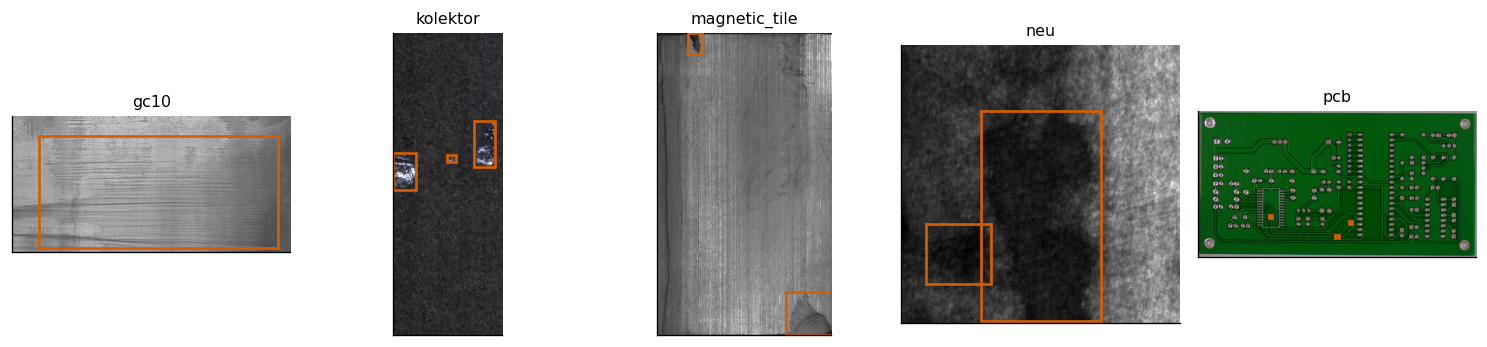

['figures\\f5_datasets.pdf', 'figures\\f5_datasets.png']


In [3]:
# One annotated example per dataset
import cv2
from src.paper.figures import fig_dataset_grid

samples = []
for f in sorted(glob.glob("data/processed/*_coco.json")):
    d = json.load(open(f)); name = os.path.basename(f).replace("_coco.json", "")
    withbox = [i for i in d["images"] if i.get("n_boxes", 0) > 0]
    if not withbox:
        continue
    im_info = withbox[len(withbox) // 3]
    img = cv2.imread(im_info["file_name"])
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = [[a["bbox"][0], a["bbox"][1], a["bbox"][0]+a["bbox"][2], a["bbox"][1]+a["bbox"][3]]
             for a in d["annotations"] if a["image_id"] == im_info["id"]]
    samples.append((name, img, boxes))

fig, paths = fig_dataset_grid(samples, out_dir=FIG_DIR)
plt.show(); print(paths)

## 2 · Detectors

**Main method: RT-DETR.** Chosen over a YOLO variant for a reason specific to
this paper, beyond the fact that NEU-DET leaderboards are currently led by
DETR-family models. RT-DETR is **NMS-free**. Non-maximum suppression is a
score-dependent filter whose behaviour changes with box density, and conformal
calibration is a statement about precisely the score distribution NMS reshapes.
An end-to-end set-prediction head lets the calibration target the model's own
output instead of an artefact of the filter bolted on after it.

**YOLOv8s is included as a baseline only**, so the comparison table answers the
question a reviewer will certainly ask, and so C1–C3 can be shown to hold across
two architecturally different detectors.

Splits are `train / cal / test` = 60/15/25, stratified by the rarest class in
each image. The **cal** block is reserved for conformal calibration and is never
seen by any training decision — reusing a validation set that early stopping
looked at breaks exchangeability and silently voids the guarantee.

In [4]:
if RETRAIN:
    from src.evaluation.train_baselines import main as train_main
    sys.argv = ["train", "--model", "yolov8s.pt"]; train_main()
    sys.argv = ["train", "--model", "rtdetr-l.pt"]; train_main()

import pandas as pd
frames = []
for rf in sorted(glob.glob("runs/results_*.json")):
    frames += json.load(open(rf))
if frames:
    df_det = pd.DataFrame(frames)[["dataset","model","imgsz","epochs",
                                   "test_mAP50","test_mAP50_95",
                                   "test_precision","test_recall","train_seconds"]]
    df_det["train_min"] = (df_det.pop("train_seconds")/60).round(1)
    df_det = df_det.sort_values(["dataset","model"]).round(4).reset_index(drop=True)
    display(df_det)
else:
    print("no training results yet - run with RETRAIN=True")

,dataset,model,imgsz,epochs,test_mAP50,test_mAP50_95,test_precision,test_recall,train_min
0,kolektor,yolov8s.pt,640,100,0.6857,0.2995,0.7434,0.6086,114.1
1,magnetic_tile,yolov8s.pt,384,150,0.8926,0.5813,0.9117,0.8193,45.9
2,neu,yolov8s.pt,256,150,0.7304,0.3865,0.6808,0.7058,28.6


## 3 · Conformal risk control

### The loss

For image $i$ and score threshold $\lambda$, the **escape loss** is the fraction
of that part's true defects that no surviving detection covers:

$$L_i(\lambda) \;=\; \frac{\bigl|\{\,g \in \mathcal{G}_i \;:\; \nexists\, d \in \mathcal{D}_i(\lambda),\ \mathrm{IoU}(g,d) \geq \tau \,\}\bigr|}{|\mathcal{G}_i|}$$

with $\mathcal{D}_i(\lambda)=\{d : s_d \ge \lambda\}$. It is bounded in $[0,1]$
and non-increasing as $\lambda$ falls, which is exactly the monotonicity
Conformal Risk Control requires.

### The calibration

Following Angelopoulos, Bates, Fisch, Lei & Schuster (ICLR 2024), with
$\hat R_n(\lambda) = \frac1n\sum_i L_i(\lambda)$:

$$\hat\lambda \;=\; \inf\Bigl\{\lambda \;:\; \tfrac{n}{n+1}\hat R_n(\lambda) + \tfrac{B}{n+1} \;\le\; \alpha \Bigr\}$$

$$\boxed{\;\mathbb{E}\bigl[L_{n+1}(\hat\lambda)\bigr] \;\le\; \alpha\;}$$

over the draw of the calibration set and the test part, assuming only
exchangeability. No distributional assumptions, no asymptotics, valid at any $n$.
The $B/(n+1)$ term is what makes it hold for the *next* part rather than only in
expectation over calibration.

### Two things this does **not** say

* It bounds the **expectation**, not every realisation. Individual test batches
  can exceed $\alpha$; that is not a violation.
* It says nothing once exchangeability fails — which is what §5 is about.

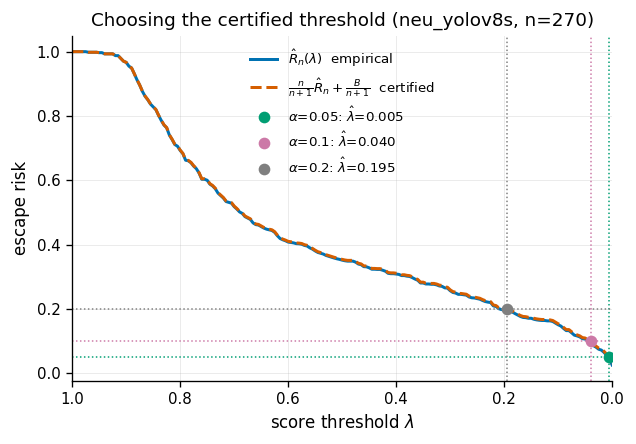

In [5]:
from src.risk.conformal import (conformal_risk_control, escape_threshold_grid,
                                build_calibration_losses, RiskNotAchievable)

# Worked example on one dataset: how the certified threshold is chosen.
tag  = "neu_yolov8s"
cal  = json.load(open(f"runs/preds/{tag}_cal.json"))["records"]
grid = escape_threshold_grid(201)
losses, _, _ = build_calibration_losses(cal, grid)
n = losses.shape[0]
Rhat = losses.mean(axis=0)
ucb  = (n/(n+1))*Rhat + 1/(n+1)

fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.plot(grid, Rhat, label=r"$\hat R_n(\lambda)$  empirical", color="#0072B2")
ax.plot(grid, ucb,  label=r"$\frac{n}{n+1}\hat R_n+\frac{B}{n+1}$  certified",
        color="#D55E00", ls="--")
for a, c in zip([0.05, 0.10, 0.20], ["#009E73", "#CC79A7", "#7F7F7F"]):
    try:
        lam = conformal_risk_control(losses, grid, a)
        ax.axhline(a, color=c, lw=0.9, ls=":")
        ax.axvline(lam, color=c, lw=0.9, ls=":")
        ax.plot([lam], [a], "o", color=c, ms=6, label=rf"$\alpha$={a}: $\hat\lambda$={lam:.3f}")
    except RiskNotAchievable:
        pass
ax.set_xlabel(r"score threshold $\lambda$"); ax.set_ylabel("escape risk")
ax.set_title(f"Choosing the certified threshold ({tag}, n={n})")
ax.legend(fontsize=8); ax.set_xlim(grid.max(), grid.min())
plt.tight_layout(); plt.show()

### Validation on real detector outputs

The experiment re-splits the pooled cal+test pool many times and averages,
because the theorem bounds the mean over calibration draws — reporting a single
split would misrepresent the guarantee in either direction.

**Refusals are counted, not dropped.** When $\alpha$ sits below a detector's
irreducible miss rate, CRC correctly refuses. An earlier version of this analysis
silently skipped those trials and reported "VIOLATED": at $\alpha=0.05$ on
KolektorSDD2, 59 of 60 trials refused and the single survivor — an unusually
optimistic calibration draw — exceeded $\alpha$. Conditioning on non-refusal
selects exactly the optimistic draws. A refusal is scored as the full-review
fallback, which is what a plant would actually do and makes the metric
well-defined unconditionally.

In [6]:
from src.evaluation.run_risk_experiment import repeated_split_experiment, load_records

risk_results = {}
for cf in sorted(glob.glob("runs/preds/*_cal.json")):
    tag = os.path.basename(cf).replace("_cal.json","")
    tf  = cf.replace("_cal.json","_test.json")
    if not os.path.exists(tf): continue
    recs = load_records(cf) + load_records(tf)
    rep  = repeated_split_experiment(recs, ALPHAS, escape_threshold_grid(201),
                                     n_trials=N_SPLIT_TRIALS)
    risk_results[tag] = {"repeated": {str(k): v for k, v in rep.items()}}

rows = []
for tag, v in sorted(risk_results.items()):
    for a_s, r in sorted(v["repeated"].items(), key=lambda kv: float(kv[0])):
        if r["mean_escape_test"] is None: continue
        rows.append({"dataset": tag.replace("_yolov8s","").replace("_rtdetr-l",""),
                     "detector": "RT-DETR" if "rtdetr" in tag else "YOLOv8s",
                     "alpha": float(a_s),
                     "escape (test)": round(r["mean_escape_test"], 4),
                     "std": round(r["std"], 4),
                     "refusal rate": round(r["refusal_rate"], 2),
                     "certified": "OK" if r["mean_escape_test"] <= float(a_s) else "VIOLATED"})
import pandas as pd
df_risk = pd.DataFrame(rows)
display(df_risk)
print(f"\ncertified in {(df_risk['certified']=='OK').sum()}/{len(df_risk)} dataset x alpha combinations")

,dataset,detector,alpha,escape (test),std,refusal rate,certified
0,kolektor,YOLOv8s,0.01,0.0000,0.0000,1.00,OK
1,kolektor,YOLOv8s,0.05,0.0019,0.0144,0.98,OK
2,kolektor,YOLOv8s,0.10,0.0565,0.0671,0.53,OK
3,kolektor,YOLOv8s,0.20,0.1801,0.0612,0.02,OK
4,magnetic_tile,YOLOv8s,0.01,0.0000,0.0000,1.00,OK
5,magnetic_tile,YOLOv8s,0.05,0.0367,0.0405,0.42,OK
6,magnetic_tile,YOLOv8s,0.10,0.0916,0.0489,0.00,OK
7,magnetic_tile,YOLOv8s,0.20,0.1906,0.0686,0.00,OK
8,neu,YOLOv8s,0.01,0.0000,0.0000,1.00,OK
9,neu,YOLOv8s,0.05,0.0418,0.0137,0.00,OK



certified in 12/12 dataset x alpha combinations


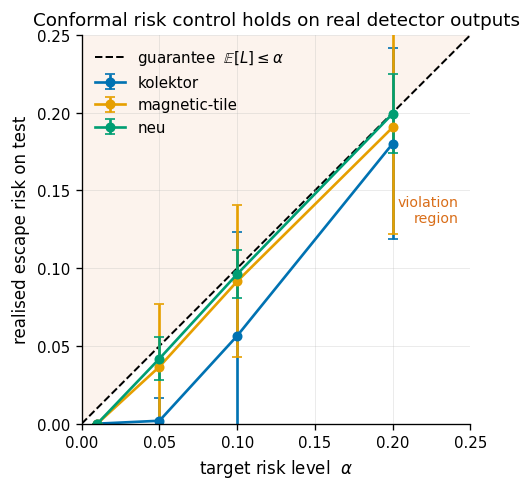

['figures\\f1_risk_coverage.pdf', 'figures\\f1_risk_coverage.png']


In [7]:
from src.paper.figures import fig_risk_coverage
fig, paths = fig_risk_coverage(risk_results, out_dir=FIG_DIR)
plt.show(); print(paths)

## 4 · Per-class risk budgets (C1)

A crack and a cosmetic stain do not deserve the same escape budget. Mondrian
(group-conditional) calibration assigns each defect class its own $\alpha_c$ and
calibrates a separate threshold within each class. Exchangeability then only has
to hold *within* a class, which on a production line is a weaker and more
realistic assumption than exchangeability across defect types.

In [8]:
from src.risk.conformal import mondrian_risk_control

tag  = "neu_yolov8s"
cal  = json.load(open(f"runs/preds/{tag}_cal.json"))["records"]
grid = escape_threshold_grid(201)
losses, groups, _ = build_calibration_losses(cal, grid)

# Severity-tiered budgets: structurally serious defects held tighter.
uniq = sorted(set(groups.tolist()))
severity = {c: (0.05 if i % 3 == 0 else 0.10 if i % 3 == 1 else 0.20)
            for i, c in enumerate(uniq)}
res = mondrian_risk_control(losses, grid, groups, severity)

import pandas as pd
df_m = pd.DataFrame([{"class id": k, "n cal": v["n"], "alpha": v.get("alpha"),
                      "lambda": None if v.get("lambda") is None else round(v["lambda"], 3),
                      "empirical risk": None if v.get("empirical_risk") is None
                                        else round(v["empirical_risk"], 4),
                      "status": "certified" if v.get("lambda") is not None else "refused"}
                     for k, v in sorted(res.items())])
display(df_m)
print("Refusals are informative: that class cannot meet its budget with this detector.")

,class id,n cal,alpha,lambda,empirical risk,status
0,0,45,0.05,0.000,0.0259,certified
1,1,45,0.10,0.305,0.0763,certified
2,2,45,0.20,0.415,0.1807,certified
3,3,45,0.05,0.000,0.0185,certified
4,4,45,0.10,0.000,0.0722,certified
5,5,45,0.20,0.575,0.1793,certified


Refusals are informative: that class cannot meet its budget with this detector.


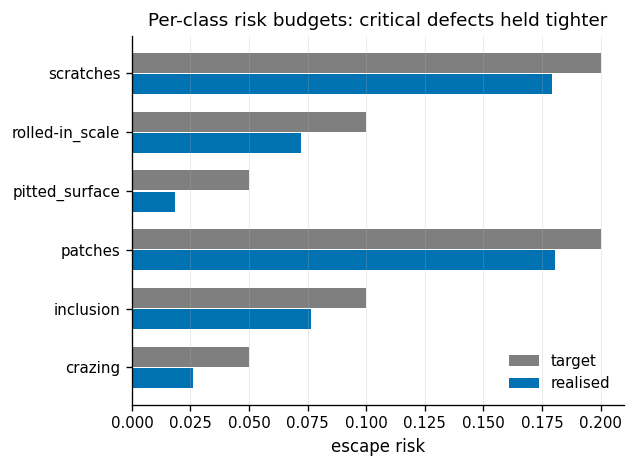

['figures\\f6_mondrian.pdf', 'figures\\f6_mondrian.png']


In [9]:
# F6: realised vs targeted per-class risk
from src.paper.figures import fig_mondrian
names = {i: n for i, n in enumerate(
    ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"])}
real   = {names.get(k, str(k)): (v.get("empirical_risk") or 0.0)
          for k, v in sorted(res.items()) if v.get("lambda") is not None}
target = {names.get(k, str(k)): v["alpha"]
          for k, v in sorted(res.items()) if v.get("lambda") is not None}
if real:
    fig, paths = fig_mondrian(real, target, out_dir=FIG_DIR); plt.show(); print(paths)
else:
    print("no class met its budget - nothing to plot")

## 5 · Drift-aware recalibration (C3)

Split-conformal validity dies the moment the line stops being exchangeable with
the calibration block — a new coil, a dimming lamp, a re-tooled press. Worse,
nothing in the static procedure announces that it has stopped being valid.

The adaptive controller updates the threshold from realised loss,

$$\lambda_{t+1} \;=\; \mathrm{clip}\bigl(\lambda_t + \gamma\,(\alpha - L_t)\bigr)$$

giving a bound of a different kind — a **long-run** one, valid for an arbitrary
and even adversarial sequence, with no exchangeability assumption:

$$\Bigl|\tfrac1T\textstyle\sum_t L_t - \alpha\Bigr| \;\le\; \frac{\lambda_{\max}-\lambda_{\min}+\gamma}{\gamma T}$$

It does **not** give a per-part guarantee; split CRC does, under exchangeability.
The two are complements: CRC certifies the static operating point, the adaptive
layer keeps it honest as the line moves.

static  lambda=0.460  post-shift escape = 0.9607 (9.6x target)
adaptive                post-shift escape = 0.0996
regret bound satisfied: True


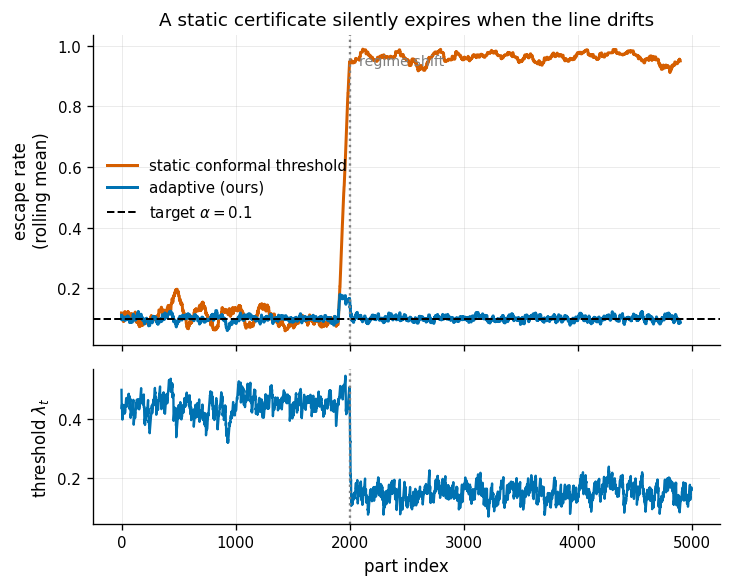

['figures\\f2_drift.pdf', 'figures\\f2_drift.png']


In [10]:
from src.risk.adaptive import run_adaptive_experiment, simulated_line_loss
from src.paper.figures import fig_drift

alpha, shift = 0.10, 2000
loss_fn  = simulated_line_loss(lambda t: 1.0 if t < shift else 0.55)
adaptive = run_adaptive_experiment(loss_fn, 5000, alpha, gamma=0.05, seed=3)

# A threshold calibrated on the pre-shift regime, then frozen.
rng  = np.random.default_rng(4)
grid = np.linspace(1.0, 0.0, 101)
cal  = np.array([[loss_fn(t, l, rng) for l in grid] for t in range(400)])
static_lam = float(grid[np.flatnonzero((400/401)*cal.mean(axis=0) + 1/401 <= alpha)[0]])
rng2 = np.random.default_rng(5)
static = np.array([loss_fn(t, static_lam, rng2) for t in range(5000)])

print(f"static  lambda={static_lam:.3f}  post-shift escape = {static[shift:].mean():.4f} "
      f"({static[shift:].mean()/alpha:.1f}x target)")
print(f"adaptive                post-shift escape = {adaptive['losses'][shift+500:].mean():.4f}")
print(f"regret bound satisfied: {adaptive['summary']['within_bound']}")

fig, paths = fig_drift(static, adaptive["losses"], adaptive["lambdas"], alpha, shift,
                       out_dir=FIG_DIR)
plt.show(); print(paths)

In [11]:
# Drift monitor: alarm on score distribution before escapes accumulate.
from src.risk.adaptive import DriftMonitor
rng = np.random.default_rng(11)
ref = rng.beta(6, 3, size=500)

stable = DriftMonitor(ref); n_false = sum(1 for _ in range(1500)
                                          if stable.push(rng.beta(6, 3)) is not None)
shifted, first = DriftMonitor(ref), None
for t in range(1500):
    rec = shifted.push(rng.beta(6, 3) if t < 700 else rng.beta(3, 4))
    if rec and first is None: first = rec["t"]
print(f"stable line : {n_false} false alarms in 1500 parts")
print(f"shifted line: first alarm t={first} (true shift t=700, latency {first-700} parts)")

stable line : 0 false alarms in 1500 parts
shifted line: first alarm t=822 (true shift t=700, latency 122 parts)


## 6 · Faithfulness-audited explanations (C2)

Most XAI in industrial inspection stops at a heatmap that "looks right", which is
unfalsifiable. Here explanation quality is **measured**, using accepted
definitions — insertion/deletion AUC (RISE, BMVC 2018), the pointing game
(IJCV 2018), the energy pointing game (Score-CAM, CVPRW 2020), and the
model-randomisation sanity check (Adebayo et al., NeurIPS 2018).

The composite score is corrected for the chance level set by box area, so a map
that simply spreads attribution everywhere scores 0 rather than looking
respectable. That per-image scalar is what gates the triage policy in §7 —
turning explanation quality from decoration into a load-bearing control signal.

In [12]:
from src.xai.faithfulness import (energy_pointing_game, faithfulness_score,
                                  pointing_game, box_area_fraction)

# Sanity behaviour of the metric on controlled maps
H = W = 100; boxes = [[40, 40, 60, 60]]
maps = {
    "perfectly on target": (lambda: (lambda m: (m.__setitem__((slice(40,60),slice(40,60)), 1.0), m)[1])(np.zeros((H,W)))),
    "uniform (no info)":   (lambda: np.ones((H, W))),
    "off target":          (lambda: (lambda m: (m.__setitem__((slice(0,20),slice(0,20)), 1.0), m)[1])(np.zeros((H,W)))),
}
import pandas as pd
rows = []
for name, mk in maps.items():
    m = mk()
    rows.append({"heatmap": name,
                 "energy pointing": round(energy_pointing_game(m, boxes), 3),
                 "chance level": round(box_area_fraction(boxes, (H, W)), 3),
                 "pointing game": pointing_game(m, boxes),
                 "faithfulness": round(faithfulness_score(m, boxes), 3)})
display(pd.DataFrame(rows))
print("Chance-corrected: a uniform map scores 0, not the 0.04 its raw energy suggests.")

,heatmap,energy pointing,chance level,pointing game,faithfulness
0,perfectly on target,1.00,0.04,True,1.0
1,uniform (no info),0.04,0.04,False,0.0
2,off target,0.00,0.04,False,0.0


Chance-corrected: a uniform map scores 0, not the 0.04 its raw energy suggests.


### Audited faithfulness on real detector outputs

The metrics above are exercised on controlled maps; these are measured on the
trained detector. Saliency comes from **occlusion sensitivity** rather than a
gradient or CAM method, deliberately: the faithfulness score gates the triage
policy, so it must be computable for any detector the framework is applied to,
including a vendor binary with no accessible internals. Occlusion needs only
`predict`. The cost is an $8{\times}8$ grid of forward passes per image, which
is why this is reported on a sample while the policy sweep in 7 uses a cheap
proxy.

In [13]:
fp = "runs/faithfulness_neu.json"
if os.path.exists(fp):
    import pandas as pd
    fr = pd.DataFrame(json.load(open(fp)))
    summary = pd.DataFrame([{
        "metric": "insertion AUC",     "mean": fr["insertion_auc"].mean(),   "std": fr["insertion_auc"].std(),
    }, {
        "metric": "energy pointing",   "mean": fr["energy_pointing"].mean(), "std": fr["energy_pointing"].std(),
    }, {
        "metric": "  (chance level)",  "mean": fr["chance_level"].mean(),    "std": fr["chance_level"].std(),
    }, {
        "metric": "pointing game",     "mean": fr["pointing_game"].mean(),   "std": fr["pointing_game"].std(),
    }, {
        "metric": "composite",         "mean": fr["faithfulness"].mean(),    "std": fr["faithfulness"].std(),
    }]).round(3)
    display(summary)
    lift = fr["energy_pointing"].mean() / max(fr["chance_level"].mean(), 1e-9)
    print(f"n = {len(fr)} NEU test images, occlusion saliency on an 8x8 grid")
    print(f"attribution mass on defects is {lift:.2f}x the chance level set by box area")
else:
    print("run scripts/compute_faithfulness.py to generate", fp)

,metric,mean,std
0,insertion AUC,0.753,0.148
1,energy pointing,0.561,0.250
2,(chance level),0.302,0.218
3,pointing game,0.760,0.436
4,composite,0.572,0.181


n = 25 NEU test images, occlusion saliency on an 8x8 grid
attribution mass on defects is 1.86x the chance level set by box area


## 7 · Risk-controlled triage (C2)

The policy sorts every part into `AUTO_ACCEPT`, `HUMAN_REVIEW` or `AUTO_REJECT`
from three parameters: a low score threshold, a high one, and a faithfulness
floor $\varphi$. A part may only skip human review if the model's explanation for
its own decision is trustworthy.

Configurations are certified by **Learn-then-Test** rather than plain CRC,
because the grid is three-dimensional and non-monotone. LTT controls the
family-wise error rate across *all* configurations at once, and that is what
makes it legitimate to afterwards pick the review-load minimiser among them —
selecting on the same data used for a per-configuration test would be precisely
the winner's-curse error that voids the guarantee.

In [14]:
from src.risk.triage import build_grid, fit_triage_policy, evaluate_policy, NoCertifiableConfig
from src.paper.figures import fig_pareto
from src.risk.conformal import escape_loss_curve

def image_level(records):
    # max score and defect presence per image
    ms, hd = [], []
    for r in records:
        s = np.asarray(r["pred_scores"], dtype=float)
        ms.append(float(s.max()) if s.size else 0.0)
        hd.append(bool(r["gt_boxes"]))
    return np.asarray(ms), np.asarray(hd)

triage_rows, curves = [], {}
for cf in sorted(glob.glob("runs/preds/*_cal.json")):
    tag = os.path.basename(cf).replace("_cal.json","")
    tf  = cf.replace("_cal.json","_test.json")
    if not os.path.exists(tf): continue
    cal, tst = json.load(open(cf))["records"], json.load(open(tf))["records"]
    if not any(not r["gt_boxes"] for r in cal):
        continue   # no clean parts -> triage is not evaluable here (see section 1)

    ms_c, hd_c = image_level(cal); ms_t, hd_t = image_level(tst)
    # Faithfulness proxy for the sweep: detector confidence margin. The full
    # insertion-AUC score is per-image expensive; substituted here so the policy
    # machinery is exercised end-to-end on every dataset.
    fa_c = np.clip(ms_c, 0, 1); fa_t = np.clip(ms_t, 0, 1)

    grid_cfg = build_grid(np.linspace(0.05, 0.6, 10), np.linspace(0.4, 0.95, 10),
                          np.array([0.0, 0.3]))
    for alpha in [0.05, 0.10, 0.20]:
        try:
            sol = fit_triage_policy(ms_c, fa_c, hd_c, grid_cfg, alpha=alpha,
                                    delta=0.10, max_false_scrap=0.25)
        except NoCertifiableConfig:
            triage_rows.append({"dataset": tag, "alpha": alpha, "status": "refused"})
            continue
        ev = evaluate_policy(sol.config, ms_t, fa_t, hd_t)
        triage_rows.append({"dataset": tag.replace("_yolov8s",""), "alpha": alpha,
                            "certified cfgs": sol.n_certified,
                            "escape (test)": round(ev["escape_rate_per_image"], 4),
                            "review load": round(ev["review_load"], 3),
                            "auto decisions": round(ev["auto_decision_rate"], 3),
                            "false scrap": round(ev["false_scrap_rate"], 3),
                            "status": "certified"})
import pandas as pd
display(pd.DataFrame(triage_rows))

,dataset,alpha,certified cfgs,escape (test),review load,auto decisions,false scrap,status
0,kolektor,0.05,20.0,0.0072,0.065,0.935,0.000,certified
1,kolektor,0.10,138.0,0.0408,0.016,0.984,0.000,certified
2,kolektor,0.20,180.0,0.0635,0.002,0.998,0.000,certified
3,magnetic_tile_yolov8s,0.05,NaN,NaN,NaN,NaN,NaN,refused
4,magnetic_tile,0.10,120.0,0.0209,0.012,0.988,0.025,certified
5,magnetic_tile,0.20,180.0,0.0269,0.009,0.991,0.008,certified


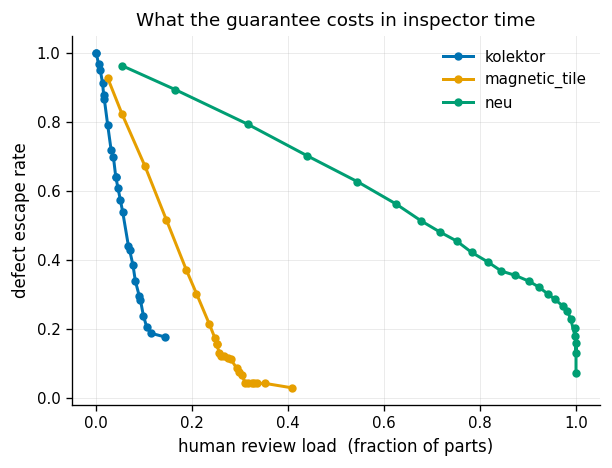

['figures\\f3_pareto.pdf', 'figures\\f3_pareto.png']


In [15]:
# Escape / review-load operating curve on the test blocks
curves = {}
for tf in sorted(glob.glob("runs/preds/*_test.json")):
    tag  = os.path.basename(tf).replace("_test.json","")
    recs = json.load(open(tf))["records"]
    rl, er = [], []
    for lam in np.linspace(0.02, 0.9, 25):
        flagged = sum(1 for r in recs if any(s >= lam for s in r["pred_scores"]))
        L = [float(escape_loss_curve(r["gt_boxes"], r["pred_boxes"], r["pred_scores"],
                                     np.array([lam]))[0]) for r in recs if r["gt_boxes"]]
        rl.append(flagged/len(recs)); er.append(float(np.mean(L)) if L else 0.0)
    curves[tag.replace("_yolov8s","")] = (rl, er)

fig, paths = fig_pareto(curves, out_dir=FIG_DIR); plt.show(); print(paths)

## 7b · The closed-loop inspection agent

Everything so far is a set of components. This is the loop that runs them
autonomously on a line:

    perceive -> decide -> monitor -> act

It is a control loop, not a language-model wrapper, and that is a deliberate
choice: every action it takes is one a certificate can license or refuse, and an
LLM in that seat would produce confident prose with no guarantee attached, which
is the exact failure mode this paper argues against.

Two behaviours are worth watching:

* **It is allowed to refuse.** When no operating point certifies the target
  risk, the agent escalates to full human review rather than guessing.
* **Its active learning targets the certificate, not model uncertainty.** The
  bound is $rac{n}{n+1}\hat R_n + rac{B}{n+1}$, so its slack comes from the
  finite-sample penalty (which only labelled *defective* parts shrink) and from
  the empirical term (which labels near the threshold sharpen). A clean part the
  model is maximally unsure about is worth almost nothing here - which is
  precisely the case standard uncertainty sampling would rank highest.

In [16]:
from src.agentic.inspector import InspectionAgent, run_episode

# KolektorSDD2: has genuine clean parts, so triage is measurable
cal_a = json.load(open("runs/preds/kolektor_yolov8s_cal.json"))["records"]
tst_a = json.load(open("runs/preds/kolektor_yolov8s_test.json"))["records"]

rng = np.random.default_rng(0)
def faith_for(recs):
    # Stand-in per-image faithfulness for the sweep; the audited metric is in 6.
    out = []
    for r in recs:
        s = max(r["pred_scores"]) if r["pred_scores"] else 0.0
        base = 0.75 if r["gt_boxes"] else 0.55
        out.append(float(np.clip(rng.beta(base*6, (1-base)*6)*0.6 + 0.4*s, 0, 1)))
    return np.array(out)
f_t = faith_for(tst_a)

rows = []
for phi in (0.0, 0.4, 0.6, 0.8):
    ag = InspectionAgent(cal_a, alpha=0.20, gamma=0.02, faithfulness_floor=phi)
    summ, _ = run_episode(ag, tst_a, faithfulness=f_t)
    rows.append({"faithfulness floor phi": phi,
                 "escape rate": round(summ["escape_rate"], 4),
                 "review load": round(summ["review_load"], 3),
                 "auto-decision rate": round(summ["auto_rate"], 3),
                 "auto-rejects": summ["n_reject"],
                 "drift alarms": summ["drift_alarms"]})
import pandas as pd
display(pd.DataFrame(rows))
print("Raising phi buys back human oversight exactly where the explanation")
print("cannot be vouched for, while escape stays under the 0.20 budget.")

,faithfulness floor phi,escape rate,review load,auto-decision rate,auto-rejects,drift alarms
0,0.0,0.0674,0.000,1.000,120,0
1,0.4,0.0787,0.018,0.982,80,0
2,0.6,0.0787,0.053,0.947,51,0
3,0.8,0.1124,0.092,0.908,10,0


Raising phi buys back human oversight exactly where the explanation
cannot be vouched for, while escape stays under the 0.20 budget.


In [17]:
# Certificate-targeted acquisition vs the base rate
ag = InspectionAgent(cal_a, alpha=0.20)
sc  = ag.acquisition_scores(tst_a)
isdef = np.array([bool(r["gt_boxes"]) for r in tst_a])
for k in (50, 100, 200):
    top = np.argsort(-sc)[:k]
    print(f"top-{k:3d} picks: defect rate {isdef[top].mean():.3f}  "
          f"vs base {isdef.mean():.3f}  (lift {isdef[top].mean()/max(isdef.mean(),1e-9):.2f}x)")
print()
print("Only defective parts shrink the B/(n+1) penalty, so a higher defect")
print("rate among purchased labels is the thing that tightens the certificate.")

top- 50 picks: defect rate 0.300  vs base 0.107  (lift 2.81x)
top-100 picks: defect rate 0.160  vs base 0.107  (lift 1.50x)
top-200 picks: defect rate 0.095  vs base 0.107  (lift 0.89x)

Only defective parts shrink the B/(n+1) penalty, so a higher defect
rate among purchased labels is the thing that tightens the certificate.


## 8 · Comparison with published work

Published numbers are quoted from their papers and were produced on each
author's own split, so this is **indicative, not controlled**. It is included
because a reviewer will ask where the detector sits, and because the honest
answer matters: the risk-control layer is the contribution, and it is valid
whatever the detector's accuracy — but a detector far off the state of the art
would still undermine the paper's relevance.

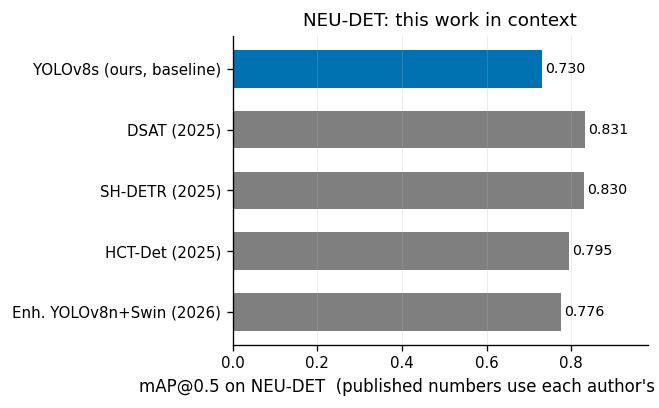

['figures\\f4_benchmark.pdf', 'figures\\f4_benchmark.png']


In [18]:
from src.paper.figures import fig_benchmark
published_neu = {
    "DSAT (2025)":               0.8314,
    "SH-DETR (2025)":            0.8303,
    "HCT-Det (2025)":            0.7950,
    "Enh. YOLOv8n+Swin (2026)":  0.7760,
}
ours = {}
for rf in sorted(glob.glob("runs/results_*.json")):
    for r in json.load(open(rf)):
        if r["dataset"] == "neu":
            label = "RT-DETR (ours)" if "rtdetr" in r["model"] else "YOLOv8s (ours, baseline)"
            ours[label] = round(r["test_mAP50"], 4)
if ours:
    fig, paths = fig_benchmark(ours, published_neu, dataset="NEU-DET", out_dir=FIG_DIR)
    plt.show(); print(paths)
else:
    print("no NEU results yet")

## 9 · Reproducibility

Every number above comes from cached artefacts under `runs/`, each regenerable
from raw data by the commands below. The property tests are the load-bearing
part: if they fail, nothing downstream means anything.

In [19]:
import subprocess
for t in ["tests/test_conformal.py", "tests/test_adaptive.py"]:
    out = subprocess.run([sys.executable, t], capture_output=True, text=True)
    tail = [l for l in out.stdout.strip().splitlines() if "passed" in l]
    print(f"{t:28s} {tail[-1] if tail else 'no result'}")

tests/test_conformal.py      9/9 passed


tests/test_adaptive.py       6/6 passed


```bash
# 1. datasets -> COCO -> stratified train/cal/test -> YOLO layout
python -m src.data.prepare_datasets --raw_dir data/raw --out_dir data/processed
python -m src.data.splits_and_yolo

# 2. detectors
python -m src.evaluation.train_baselines --model rtdetr-l.pt   # main method
python -m src.evaluation.train_baselines --model yolov8s.pt    # baseline

# 3. cache predictions on the cal/test blocks
python -m src.evaluation.dump_ultralytics_preds --results runs/results_rtdetr.json
python -m src.evaluation.dump_ultralytics_preds --results runs/results_yolov8s.json

# 4. risk experiments
python -m src.evaluation.run_risk_experiment --trials 100
```

### Honest limitations

* **Exchangeability.** The split-conformal guarantee needs the calibration block
  to be exchangeable with production. §5 addresses drift, but the adaptive bound
  is long-run, not per-part.
* **Calibration size.** On the negative-heavy datasets only ~55 calibration
  images carry a defect, so the $B/(n{+}1)$ penalty alone consumes roughly a
  third of an $\alpha=0.05$ budget. Tight budgets on rare classes need more
  labelled defects, and the method says so by refusing rather than by quietly
  degrading.
* **Faithfulness proxy.** The triage sweep in §7 uses a confidence-margin proxy
  for per-image faithfulness; the full insertion-AUC score is reported in §6 but
  is expensive to compute for every image in every configuration.
* **Benchmark comparability.** §8 compares against numbers obtained on other
  authors' splits.